<h1 style="color:#2774AE; text-align: center;">Introduction to Python — Day 3</h1>

<p align="center">
    <strong>Sai Bavisetty, PhD</strong><br>
    <em>UCLA QCBio Collaboratory | Winter 2026</em>
</p>

---

## <span style="color:#2774AE;">🗓️ Workshop Overview</span>
Welcome to the third day of the **Collaboratory Workshop: Intro to Python**. This interactive notebook contains the live-coding exercises, conceptual explanations, and practice problems for today's session.

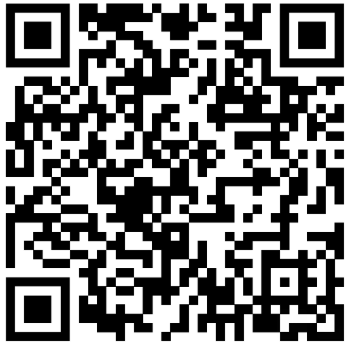

## <span style="color:#2774AE;">🔍 Homework 1: Exploratory Analysis of scRNA Sequencing Data</span>

In this investigation, our goal is to perform an exploratory data analysis (EDA) and visualization of a Single-Cell RNA Sequencing (scRNA-seq) count matrix. We are working with a dataset of approximately 68,000 Peripheral Blood Mononuclear Cells (PBMCs).

---

### **Step 1: Environment Setup & Data Loading**

The first step in any data pipeline is to import the libraries used for numerical manipulation (`numpy`), data frames (`pandas`), and plotting (`matplotlib` or `seaborn`). 



In [ ]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Code to read CSV file into DataFrame
# The format looks like this:
# df = pd.read_csv('filename.csv')



In [ ]:
# Write code to display the first few rows of the DataFrame using head()



In [ ]:
# Drop the Unnamed column


In [ ]:
# Write code to display the first 10 rows of the DataFrame


In [ ]:
# Write code to summanrize the DataFrame using describe()


### **Step 2: Library Size Distribution (Sequencing Depth)**

In scRNA-seq, the **Library Size** is the total number of unique RNA molecules (UMIs) detected within a single cell. Because the sequencing process is stochastic, some cells end up with 10,000 counts while others may only have 500. 

A cell with an extremely low library size is often an "empty droplet" or a failed library prep, whereas a cell with an extremely high count might be two cells accidentally sequenced as one.

---

#### **The Math: Summing the Rows**
To find the library size, we need to sum all gene counts for each row (cell). In Pandas, we use `.sum(axis=1)`.

**Your Task:** Calculate the total counts per cell and visualize the distribution using a histogram.



In [ ]:
# 1. Calculate the total number of UMI counts for each cell
total_counts = ...

# 2. Basic statistics
print(f"Average Library Size: {total_counts.mean():.2f}")
print(f"Median Library Size:  {total_counts.median():.2f}")
print(f"Minimum Counts:       {total_counts.min()}")
print(f"Maximum Counts:       {total_counts.max()}")

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.histplot(total_counts, bins=100, kde=True, color='#2774AE')
# Adding a vertical line for the median
plt.axvline(total_counts.median(), color='red', linestyle='--', label=f'Median: {total_counts.median()}')

plt.title("Distribution of Total UMI Counts per Cell")
plt.xlabel("Total UMI Counts")
plt.ylabel("Frequency (Number of Cells)")
plt.legend()
plt.show()

In [ ]:
# Delete garbage from memory to stop kernel crash
import gc
gc.collect()

### **Step 3: Gene Detection (Transcriptional Complexity)**

In scRNA-seq, the data is naturally **sparse**. This means that in any given cell, most genes will have a count of `0`. This happens for two reasons:
1.  **Biology:** A single cell only expresses a fraction of the total genome at any one time.
2.  **Technology:** The "capture efficiency" is not 100%; we often miss low-abundance genes (a phenomenon called "dropout").

**Gene Detection** refers to the number of *unique* genes that have at least one count in a cell. 

---

#### **The Math: Counting Non-Zero Entries**
To find the number of detected genes, we don't want to sum the counts; we want to count how many columns have a value `> 0`. 

**Your Task:** Calculate the number of unique genes expressed per cell and visualize the relationship between library size and gene detection.


In [ ]:
# 1. Count how many genes have a value greater than 0 for each cell
# We convert the dataframe to a boolean (True for >0, False for 0) and sum the Trues
genes_detected = ...

# 2. Add this to our metrics for comparison
print(f"Average genes detected per cell: {genes_detected.mean():.2f}")
print(f"Max genes detected in a single cell: {genes_detected.max()}")

# 3. Visualization: Scatter plot of Library Size vs Genes Detected
plt.figure(figsize=(10, 6))
plt.scatter(total_counts, genes_detected, alpha=1, color='#2774AE', s=1)

plt.title("Complexity Plot: Total Counts vs. Genes Detected")
plt.xlabel("Total UMI Counts (Library Size)")
plt.ylabel("Number of Unique Genes Detected")
plt.show()

In [ ]:
# Delete garbage from memory to stop kernel crash
import gc
gc.collect()

### **Step 4: Identifying the Most Frequent Genes**

Not all genes are created equal. In a typical cell, "Housekeeping" genes—which handle basic tasks like protein synthesis (Ribosomal genes) and energy production (Mitochondrial genes)—are expressed at much higher levels than specific transcription factors or signaling molecules.

If the "top" genes in your dataset are all related to cell death or red blood cell contamination, it might change how you interpret your results.

---

#### **The Math: Summing the Columns**
To find the most frequent genes, we sum the counts for each column (gene) across all 68,000 cells. 

**Your Task:** Identify the top 20 most highly expressed genes in the entire dataset and visualize their contribution as a percentage of the total data.



In [ ]:
# 1. Calculate the total sum for each gene across all cells
gene_counts = ...

# 2. Sort the genes by their total counts in descending order
top_20_genes = ...

# 3. Calculate what percentage of the TOTAL sequencing data these top 20 genes represent
total_dataset_umi = ...
top_20_percentage = (top_20_genes.sum() / total_dataset_umi) * 100

print(f"The top 20 genes account for {top_20_percentage:.2f}% of all detected RNA.")

# 4. Visualization: Bar plot of top genes
plt.figure(figsize=(12, 6))
top_20_genes.plot(kind='bar', color='#2774AE')

plt.title("Top 20 Most Highly Expressed Genes")
plt.xlabel("Gene Symbol")
plt.ylabel("Total UMI Counts Across All Cells")
plt.xticks(rotation=45)
plt.show()

### **Step 5: Visualizing Cell Health (The Mitochondrial Filter)**

When a cell’s outer membrane bursts due to stress or poor handling, the small RNA in the cytoplasm leaks out, but the larger **Mitochondria** often remain trapped inside the droplet. 

When we sequence these "broken" cells, we see a very high percentage of Mitochondrial genes (genes starting with **MT-**) and very few other genes. Identifying these cells is vital because they create noise that can ruin your clustering and lead to false biological conclusions.

---

#### **The Math: Calculating the MT-Percentage**
We need to find all columns starting with "MT-", sum them for each cell, and divide that by the cell's total library size.

**Your Task:** Calculate the percentage of mitochondrial reads per cell and determine a "death threshold."

```python


In [ ]:
# 1. Identify Mitochondrial genes (those starting with 'MT-')
mt_genes = ...

# 2. Calculate the sum of MT counts for each cell
mt_counts = ...

# 3. Calculate the percentage: (MT counts / Total Counts) * 100
# We use the 'total_counts' we calculated in Step 2
mt_percent = (mt_counts / total_counts) * 100

# 4. Visualization: Distribution of MT content
plt.figure(figsize=(10, 6))
sns.histplot(mt_percent, bins=100, color='#E74C3C', kde=True)

plt.title("Distribution of Mitochondrial Gene Percentage per Cell")
plt.xlabel("Percentage of MT Reads")
plt.ylabel("Number of Cells")
plt.axvline(5, color='black', linestyle='--', label='Common 5% Threshold')
plt.axvline(10, color='blue', linestyle='--', label='Relaxed 10% Threshold')
plt.legend()
plt.show()

### **Step 6: Exploring Gene-Gene Correlations**

Genes do not act in isolation. They work in coordinated networks. By calculating the correlation between genes, we can discover **Co-expression Modules**. 

For example, in this PBMC dataset, we expect to see strong correlations between different Mitochondrial genes (because they all function in the same organelle) or between different Ribosomal genes.

---

#### **The Math: Pearson Correlation Matrix**
Because our matrix has over 5,000 genes, a correlation matrix of the whole thing would be too large to visualize (it would be $5000 \times 5000$). Instead, we will pick a few "interesting" genes we found in Step 4 and see how they relate to each other.

**Your Task:** Select a subset of top genes and create a "Heatmap" to visualize their correlation.



In [ ]:
# 1. Select a few interesting genes (Top genes + some markers)
# Let's pick the first 15 genes from our sorted list in Step 4
interesting_genes = ...

# 2. Calculate the correlation matrix for just these genes
# We use .corr() which calculates the Pearson correlation by default
corr_matrix = ...

# 3. Visualization: Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Highly Expressed Genes")
plt.show()

In [ ]:

# 1. Select the top 50 most highly expressed genes
top_50_genes = ...
interesting_genes = ...

# 2. Calculate the correlation matrix
corr_matrix = ...



# 3. Visualization: Clean Heatmap
plt.figure(figsize=(12, 10))

# annot=False: Removes the numbers from the cells
# linewidths=0: Removes the white lines between cells for a smoother look
# vmin/vmax: Sets the color scale from -1 to 1 (standard correlation range)
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            linewidths=0, 
            square=True,
            vmin=-1, vmax=1) 

plt.title("Gene Co-expression Heatmap (Top 50 Genes)")
plt.show()

In [ ]:
# Choose two highly correlated genes from your heatmap
gene_a = ...
gene_b = ...

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x=gene_a, y=gene_b, scatter_kws={'alpha':0.1, 's':1}, line_kws={'color':'red'})
plt.title(f"Co-expression: {gene_a} vs {gene_b}")
plt.show()

### **Step 8: Dimensionality Reduction with PCA**

In a dataset with 5,000 genes, each cell is a point in a 5,000-dimensional space. This is impossible to visualize or analyze efficiently. **Principal Component Analysis (PCA)** collapses these thousands of genes into a few dozen **Principal Components (PCs)**.

Our goal is to find the minimum number of PCs required to explain **95% of the total variance** in the data.

---

#### **The Math: Scaling and Variance**
PCA is sensitive to the scale of the data. Since some genes naturally have much higher counts than others, we must **Standardize** the data (Mean = 0, Variance = 1) before running PCA.

**Your Task:** Scale the data, run PCA, and determine how many components are needed to reach the 95% threshold.

```python


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize the data (Crucial for PCA!)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 2. Initialize PCA to find enough components to explain 95% of variance
pca = PCA(n_components=0.65)
pca_data = pca.fit_transform(scaled_data)

# 3. Analyze the results
n_components = pca.n_components_
total_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Number of components to explain 95% variance: {n_components}")
print(f"Total Explained Variance: {total_variance:.2f}%")

# 4. Visualization: The Scree Plot (Cumulative Variance)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='#2774AE', lw=3)

plt.axhline(y=0.65, color='r', linestyle='--', label='65% Threshold')
plt.axvline(x=n_components, color='black', linestyle=':', label=f'{n_components} PCs')

plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
del df
del scaled_data

### **Step 10: Visualizing the "Cellular Landscape" with UMAP**

Now that we have compressed our data into Principal Components (PCs), we can use them as the input for **UMAP**. 

Unlike PCA, which projects data onto straight lines, UMAP "folds" and "stretches" the data to preserve the local relationships between cells. This results in a 2D map where distinct cell types appear as separate, identifiable clusters.

---

#### **The Tool: UMAP-learn**
We will use the PCA data we generated in Step 8. This is much faster and less noisy than running UMAP on the raw 5,000+ genes.

**Your Task:** Run the UMAP algorithm on your PCA coordinates and plot the results.




In [ ]:
import umap

# 1. Initialize UMAP
# n_neighbors: Larger values capture more global structure, smaller values capture local detail
# min_dist: Controls how tightly UMAP packs points together
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

# 2. Run UMAP on the PCA data (NOT the raw scaled data)
umap_results = reducer.fit_transform(pca_data)

# 3. Create the Visualization
plt.figure(figsize=(10, 8))
plt.scatter(umap_results[:, 0], umap_results[:, 1], s=1, alpha=0.5, cmap='Spectral')

plt.title("UMAP Projection of 68k PBMCs", fontsize=16)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(label='Cell Density/Index')
plt.show()